In [ ]:
!rm -rf /content/drive
!mkdir /content/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'DR_New_Results', 'Dataset']


In [ ]:
# checkpoint_path defined here; actual load runs after model init
checkpoint_path = "/content/drive/MyDrive/checkpoint.pth"
start_epoch = 0
# Actual loading happens in the post-model cell below

 **Import Libraries**


In [ ]:
!pip install timm imbalanced-learn
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
import matplotlib.cm as cm

In [ ]:
DRIVE_RESULTS_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"
COLAB_RESULTS_PATH = "/content/DR_New_Results/APTOS"

os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
os.makedirs(COLAB_RESULTS_PATH, exist_ok=True)

print("Drive Path:", DRIVE_RESULTS_PATH)
print("Colab Path:", COLAB_RESULTS_PATH)

Drive Path: /content/drive/MyDrive/DR_New_Results/APTOS
Colab Path: /content/DR_New_Results/APTOS


 **Reproducibility — Set Random Seed**

**OVERSAMPLING PIPELINE CODE**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

**APTOS Dataset Preprocessing**

In [ ]:
import os
import pandas as pd

aptos_root = "/content/drive/MyDrive/Dataset/Full APTOS/2019"
csv_path = os.path.join(aptos_root, "train.csv")

# load csv
aptos_df = pd.read_csv(csv_path)

# rename label
aptos_df.rename(columns={"diagnosis": "label"}, inplace=True)

# create image paths
image_dict = {}
for root, _, files in os.walk(aptos_root):
    for file in files:
        if file.endswith(".png"):
            img_id = os.path.splitext(file)[0]
            image_dict[img_id] = os.path.join(root, file)

aptos_df["image_path"] = aptos_df["id_code"].map(image_dict)

# remove missing images
aptos_df = aptos_df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Dataset loaded:", len(aptos_df))

Dataset loaded: 3662


**APTOS Dataset Balancing Visualization**

===== FULL DATASET BEFORE =====
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

===== FULL DATASET AFTER =====
label
0    1805
1    1805
2    1805
3    1805
4    1805
Name: count, dtype: int64


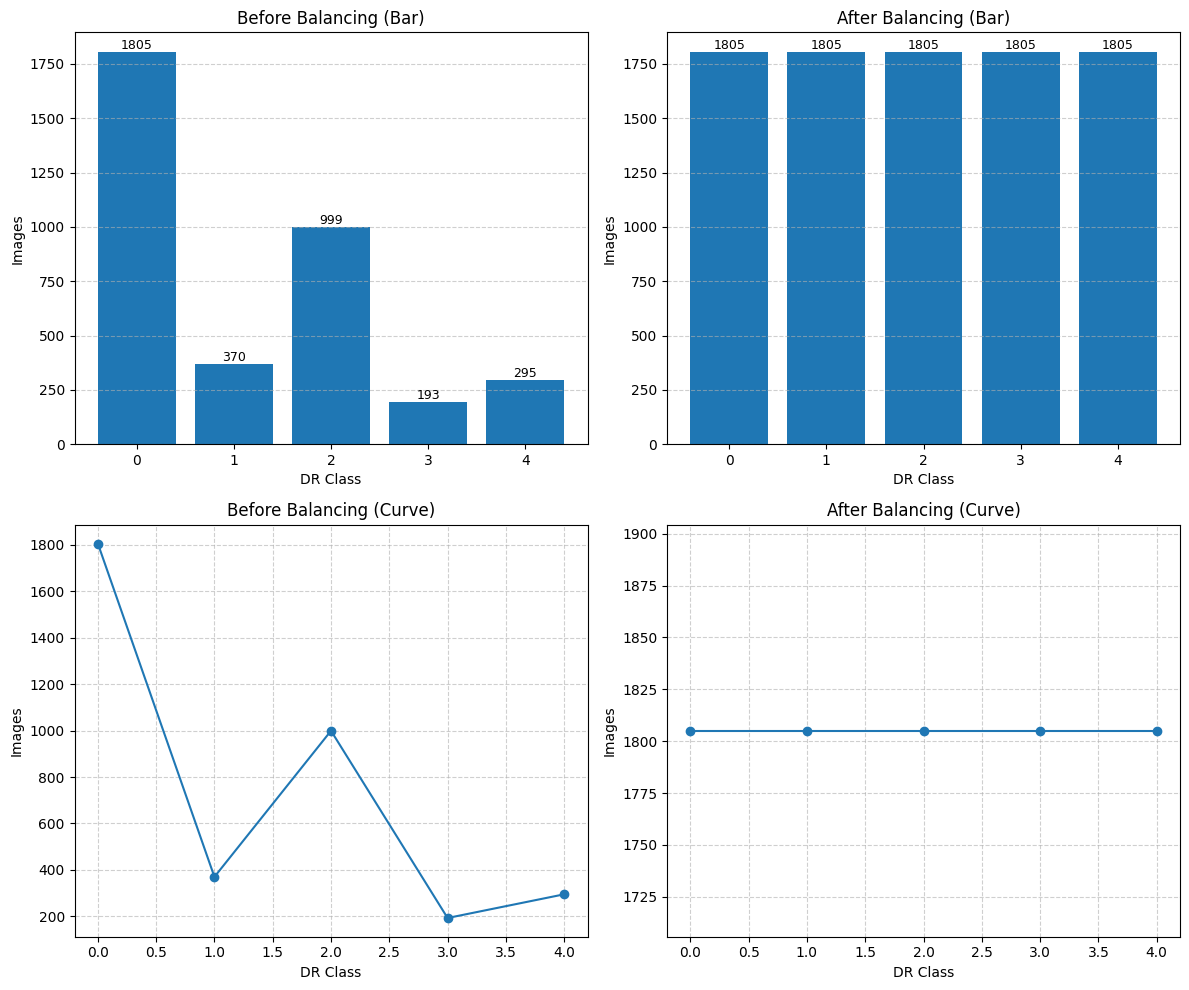


✅ Row-wise visualization (Bar + Curve) saved at: /content/drive/MyDrive/DR_New_Results/APTOS/final_distribution_rowwise.png


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# FUNCTION: ADD LABELS
# =========================
def add_labels(ax):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9)

# =========================
# FULL DATASET BEFORE
# =========================

before_counts = aptos_df["label"].value_counts().sort_index()

print("===== FULL DATASET BEFORE =====")
print(before_counts)

# =========================
# TEMP BALANCING
# =========================

max_count = before_counts.max()

balanced_temp = []

for cls in before_counts.index:
    cls_df = aptos_df[aptos_df["label"] == cls]

    sampled = cls_df.sample(
        n=max_count,
        replace=True,
        random_state=42
    )

    balanced_temp.append(sampled)

df_balanced_temp = pd.concat(balanced_temp).reset_index(drop=True)

# =========================
# AFTER DATASET
# =========================

after_counts = df_balanced_temp["label"].value_counts().sort_index()

print("\n===== FULL DATASET AFTER =====")
print(after_counts)

# =========================
# PLOT (ROW-WISE)
# =========================

fig, axes = plt.subplots(2, 2, figsize=(12,10))

# ========= ROW 1 → BAR =========

# BEFORE BAR
axes[0,0].bar(before_counts.index, before_counts.values)
add_labels(axes[0,0])
axes[0,0].set_title("Before Balancing (Bar)")
axes[0,0].set_xlabel("DR Class")
axes[0,0].set_ylabel("Images")
axes[0,0].grid(axis='y', linestyle='--', alpha=0.6)

# AFTER BAR
axes[0,1].bar(after_counts.index, after_counts.values)
add_labels(axes[0,1])
axes[0,1].set_title("After Balancing (Bar)")
axes[0,1].set_xlabel("DR Class")
axes[0,1].set_ylabel("Images")
axes[0,1].grid(axis='y', linestyle='--', alpha=0.6)

# ========= ROW 2 → CURVE =========

# BEFORE CURVE
axes[1,0].plot(before_counts.index, before_counts.values, marker='o')
axes[1,0].set_title("Before Balancing (Curve)")
axes[1,0].set_xlabel("DR Class")
axes[1,0].set_ylabel("Images")
axes[1,0].grid(True, linestyle='--', alpha=0.6)

# AFTER CURVE
axes[1,1].plot(after_counts.index, after_counts.values, marker='o')
axes[1,1].set_title("After Balancing (Curve)")
axes[1,1].set_xlabel("DR Class")
axes[1,1].set_ylabel("Images")
axes[1,1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# =========================
# SAVE
# =========================

save_path = "/content/drive/MyDrive/DR_New_Results/APTOS/final_distribution_rowwise.png"
plt.savefig(save_path, dpi=300)

plt.show()

# =========================
# FINAL MESSAGE
# =========================

print(f"\n Row-wise visualization (Bar + Curve) saved at: {save_path}")

**Dataset Class Distribution Before and After Balancing**

===== ORIGINAL DATASET =====
label
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Overlap Check:
Train-Val: 0
Train-Test: 0
Val-Test: 0

===== TRAIN AFTER BALANCING =====
label
0    1444
1    1444
2    1444
3    1444
4    1444
Name: count, dtype: int64


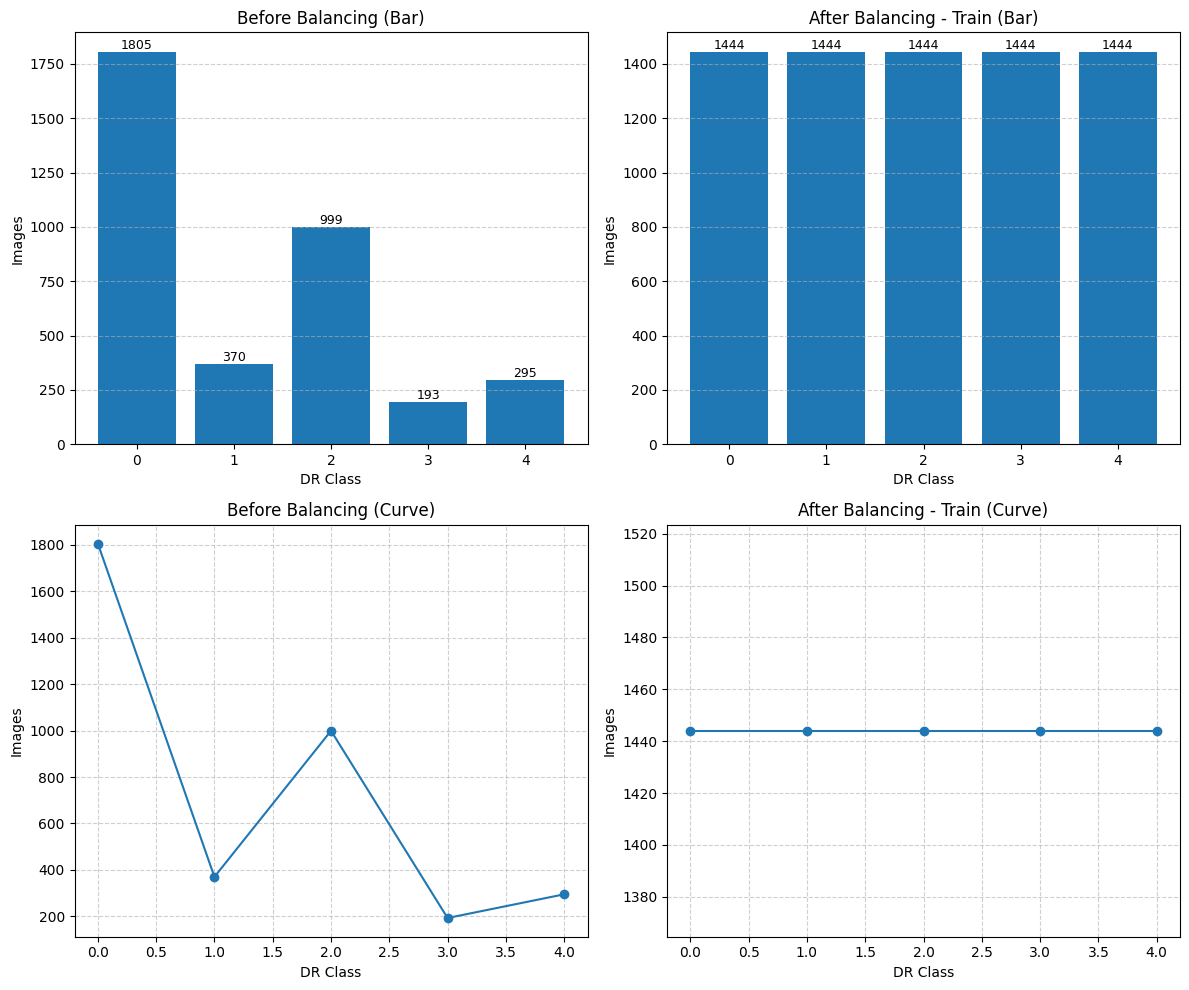


✅ Row-wise visualization (Bar + Curve) saved at: /content/drive/MyDrive/DR_New_Results/APTOS/train_distribution_rowwise.png


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# =========================
# PATH
# =========================

DRIVE_RESULTS_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"
os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)

# =========================
# FUNCTION: ADD LABELS
# =========================

def add_labels(ax):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center', va='bottom', fontsize=9)

# =========================
# STEP 1 — ORIGINAL DISTRIBUTION
# =========================

before_counts = aptos_df["label"].value_counts().sort_index()

print("===== ORIGINAL DATASET =====")
print(before_counts)

# =========================
# STEP 2 — SPLIT FIRST
# =========================

train_df, temp_df = train_test_split(
    aptos_df,
    test_size=0.2,
    stratify=aptos_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# =========================
# STEP 3 — CHECK OVERLAP
# =========================

train_set = set(train_df["image_path"])
val_set   = set(val_df["image_path"])
test_set  = set(test_df["image_path"])

print("\nOverlap Check:")
print("Train-Val:", len(train_set & val_set))
print("Train-Test:", len(train_set & test_set))
print("Val-Test:", len(val_set & test_set))

# =========================
# STEP 4 — BALANCE ONLY TRAIN
# =========================

max_count = train_df["label"].value_counts().max()

balanced = []

for cls in sorted(train_df["label"].unique()):
    cls_df = train_df[train_df["label"] == cls]

    sampled = cls_df.sample(
        n=max_count,
        replace=True,
        random_state=42
    )

    balanced.append(sampled)

train_df = pd.concat(balanced).reset_index(drop=True)

# =========================
# STEP 5 — AFTER BALANCING
# =========================

after_counts = train_df["label"].value_counts().sort_index()

print("\n===== TRAIN AFTER BALANCING =====")
print(after_counts)

# =========================
# PLOT (ROW-WISE: BAR THEN CURVE)
# =========================

fig, axes = plt.subplots(2, 2, figsize=(12,10))

# ===== ROW 1 → BAR =====

# BEFORE BAR
axes[0,0].bar(before_counts.index, before_counts.values)
add_labels(axes[0,0])
axes[0,0].set_title("Before Balancing (Bar)")
axes[0,0].set_xlabel("DR Class")
axes[0,0].set_ylabel("Images")
axes[0,0].grid(axis='y', linestyle='--', alpha=0.6)

# AFTER BAR (TRAIN ONLY)
axes[0,1].bar(after_counts.index, after_counts.values)
add_labels(axes[0,1])
axes[0,1].set_title("After Balancing - Train (Bar)")
axes[0,1].set_xlabel("DR Class")
axes[0,1].set_ylabel("Images")
axes[0,1].grid(axis='y', linestyle='--', alpha=0.6)

# ===== ROW 2 → CURVE =====

# BEFORE CURVE
axes[1,0].plot(before_counts.index, before_counts.values, marker='o')
axes[1,0].set_title("Before Balancing (Curve)")
axes[1,0].set_xlabel("DR Class")
axes[1,0].set_ylabel("Images")
axes[1,0].grid(True, linestyle='--', alpha=0.6)

# AFTER CURVE
axes[1,1].plot(after_counts.index, after_counts.values, marker='o')
axes[1,1].set_title("After Balancing - Train (Curve)")
axes[1,1].set_xlabel("DR Class")
axes[1,1].set_ylabel("Images")
axes[1,1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

# =========================
# SAVE
# =========================

save_path = os.path.join(DRIVE_RESULTS_PATH, "train_distribution_rowwise.png")
plt.savefig(save_path, dpi=300)

plt.show()

# =========================
# FINAL MESSAGE
# =========================

print(f"\n✅ Row-wise visualization (Bar + Curve) saved at: {save_path}")

**Dataset Splitting and Balancing**

===== BEFORE BALANCING =====

Train (Original):
 label
0    1444
1     296
2     799
3     154
4     236
Name: count, dtype: int64

Validation:
 label
0    180
1     37
2    100
3     20
4     29
Name: count, dtype: int64

Test:
 label
0    181
1     37
2    100
3     19
4     30
Name: count, dtype: int64

===== AFTER BALANCING =====

Train (Balanced):
 label
0    1444
1    1444
2    1444
3    1444
4    1444
Name: count, dtype: int64


/tmp/ipykernel_1180/247029896.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_train_df = train_df.groupby("label").apply(


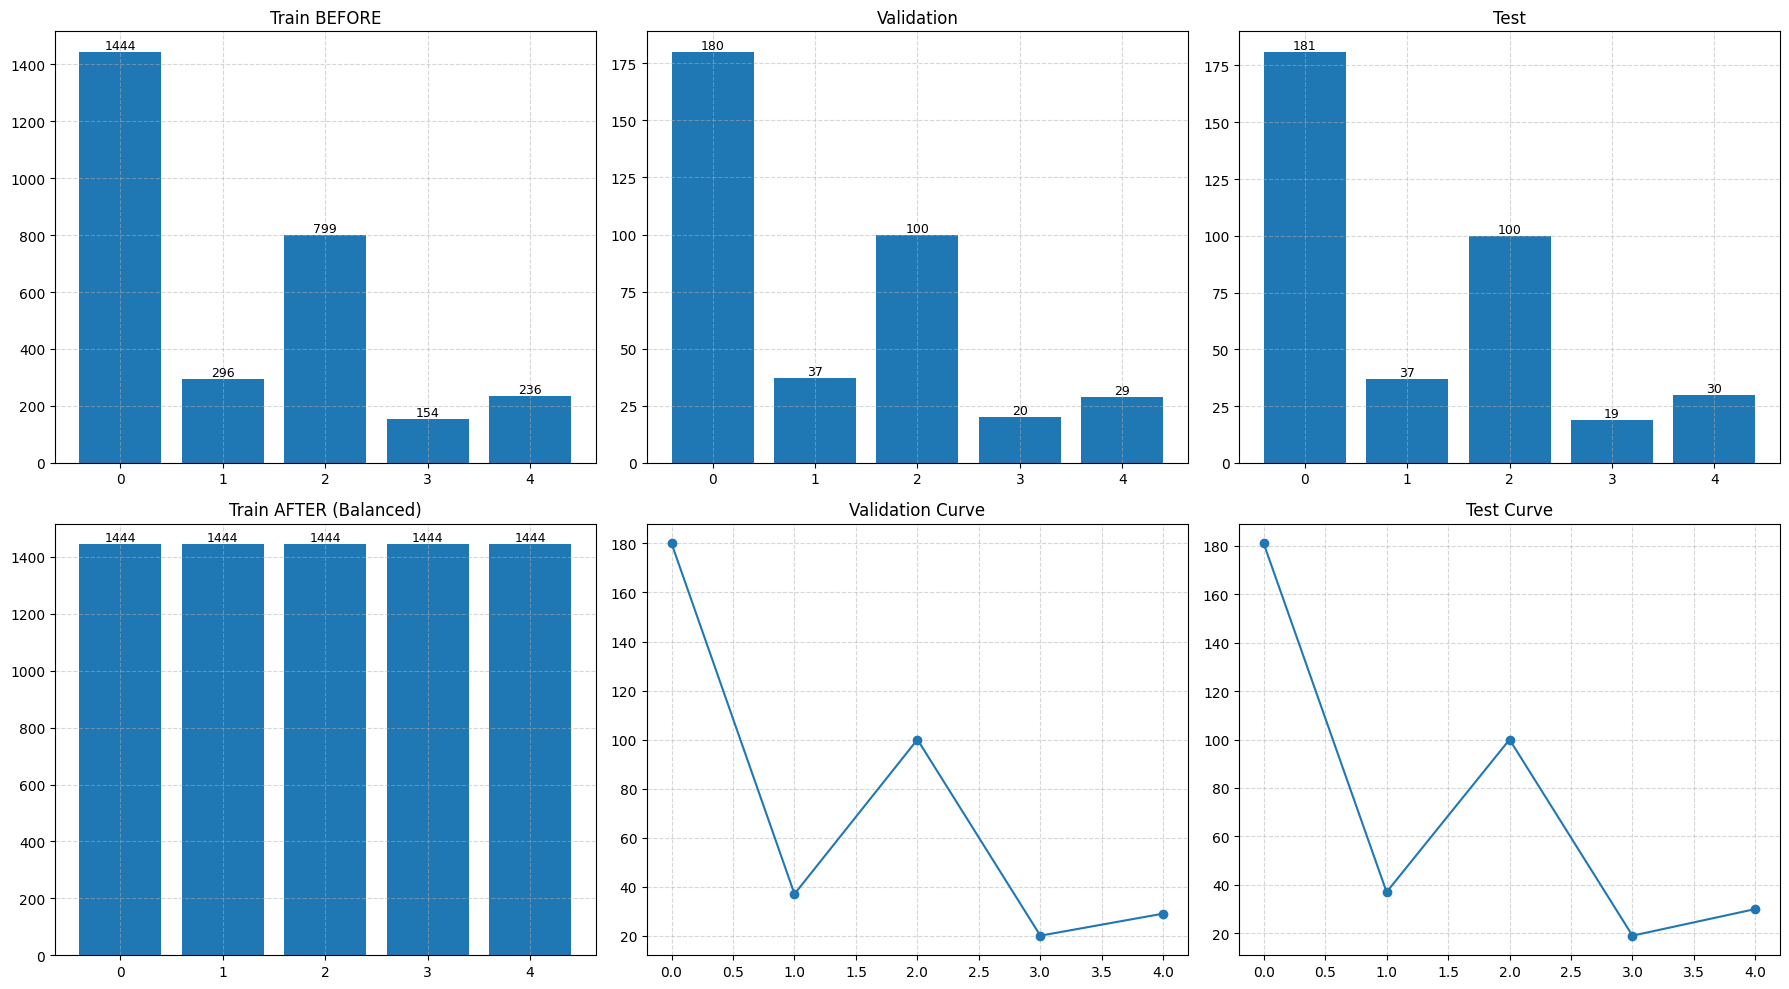


✅ Saved at: /content/drive/MyDrive/DR_New_Results/APTOS/before_after_balancing.png


In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# =========================
# FUNCTION: ADD LABELS
# =========================
def add_labels(ax, counts):
    for i, v in enumerate(counts.values):
        ax.text(counts.index[i], v, str(v), ha='center', va='bottom', fontsize=9)

# =========================
# STEP 1 — SPLIT DATA
# =========================
train_df, temp_df = train_test_split(
    aptos_df,
    test_size=0.2,
    stratify=aptos_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# =========================
# STEP 2 — BEFORE BALANCING
# =========================
print("===== BEFORE BALANCING =====")

train_counts_before = train_df["label"].value_counts().sort_index()
val_counts = val_df["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

print("\nTrain (Original):\n", train_counts_before)
print("\nValidation:\n", val_counts)
print("\nTest:\n", test_counts)

# =========================
# STEP 3 — BALANCE TRAIN SET
# =========================
max_count = train_counts_before.max()

balanced_train_df = train_df.groupby("label").apply(
    lambda x: x.sample(max_count, replace=True)
).reset_index(drop=True)

train_counts_after = balanced_train_df["label"].value_counts().sort_index()

print("\n===== AFTER BALANCING =====")
print("\nTrain (Balanced):\n", train_counts_after)

# =========================
# STEP 4 — PLOT
# =========================
fig, axes = plt.subplots(2, 3, figsize=(18,10))

# ===== ROW 1 → BEFORE =====
axes[0,0].bar(train_counts_before.index, train_counts_before.values)
add_labels(axes[0,0], train_counts_before)
axes[0,0].set_title("Train BEFORE")

axes[0,1].bar(val_counts.index, val_counts.values)
add_labels(axes[0,1], val_counts)
axes[0,1].set_title("Validation")

axes[0,2].bar(test_counts.index, test_counts.values)
add_labels(axes[0,2], test_counts)
axes[0,2].set_title("Test")

# ===== ROW 2 → AFTER =====
axes[1,0].bar(train_counts_after.index, train_counts_after.values)
add_labels(axes[1,0], train_counts_after)
axes[1,0].set_title("Train AFTER (Balanced)")

axes[1,1].plot(val_counts.index, val_counts.values, marker='o')
axes[1,1].set_title("Validation Curve")

axes[1,2].plot(test_counts.index, test_counts.values, marker='o')
axes[1,2].set_title("Test Curve")

for ax in axes.flatten():
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# =========================
# STEP 5 — SAVE
# =========================
SAVE_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"
os.makedirs(SAVE_PATH, exist_ok=True)

save_file = os.path.join(SAVE_PATH, "before_after_balancing.png")
plt.savefig(save_file, dpi=300)
plt.show()

print(f"\n Saved at: {save_file}")

# =========================
# STEP 6 — FINAL OUTPUT FOR TRAINING
# =========================

#  USE THIS FOR TRAINING
final_train_df = balanced_train_df
final_val_df = val_df
final_test_df = test_df

**Balanced Dataset Visualization**


Train Balanced:
 label
0    1444
1    1444
2    1444
3    1444
4    1444
Name: count, dtype: int64

Val Balanced:
 label
0    180
1    180
2    180
3    180
4    180
Name: count, dtype: int64

Test Balanced:
 label
0    181
1    181
2    181
3    181
4    181
Name: count, dtype: int64


/tmp/ipykernel_1180/885671185.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("label").apply(
/tmp/ipykernel_1180/885671185.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby("label").apply(
/tmp/ipykernel_1180/885671185.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas

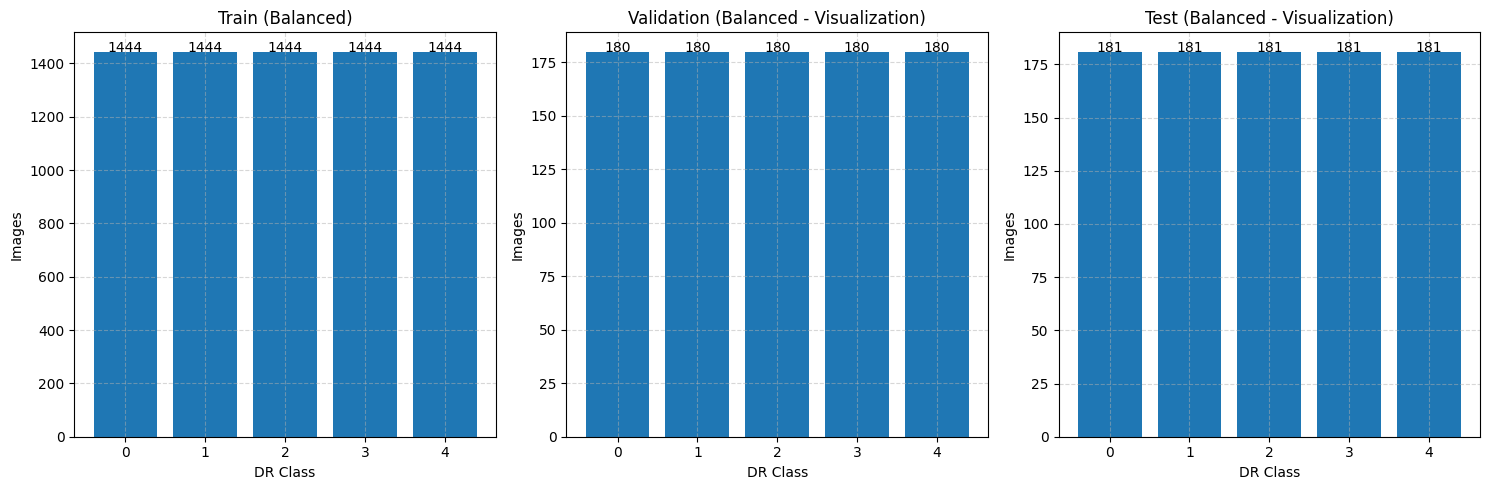


✅ Saved at: /content/drive/MyDrive/DR_New_Results/APTOS/balanced_visualization.png


In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# =========================
# PATH
# =========================
SAVE_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"
os.makedirs(SAVE_PATH, exist_ok=True)

# =========================
# SPLIT (80/10/10)
# =========================
train_df, temp_df = train_test_split(
    aptos_df,
    test_size=0.2,
    stratify=aptos_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# =========================
# 🔥 BALANCE FUNCTION
# =========================
def balance_df(df):
    max_count = df["label"].value_counts().max()
    return df.groupby("label").apply(
        lambda x: x.sample(max_count, replace=True, random_state=42)
    ).reset_index(drop=True)

# =========================
# BALANCED VERSIONS (ONLY FOR VISUALIZATION)
# =========================
train_bal = balance_df(train_df)
val_bal   = balance_df(val_df)
test_bal  = balance_df(test_df)

# =========================
# COUNTS
# =========================
train_counts = train_bal["label"].value_counts().sort_index()
val_counts   = val_bal["label"].value_counts().sort_index()
test_counts  = test_bal["label"].value_counts().sort_index()

print("\nTrain Balanced:\n", train_counts)
print("\nVal Balanced:\n", val_counts)
print("\nTest Balanced:\n", test_counts)

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15,5))

def add_labels(ax, counts):
    for i, v in enumerate(counts.values):
        ax.text(counts.index[i], v, str(v), ha='center')

# Train
axes[0].bar(train_counts.index, train_counts.values)
add_labels(axes[0], train_counts)
axes[0].set_title("Train (Balanced)")

# Validation
axes[1].bar(val_counts.index, val_counts.values)
add_labels(axes[1], val_counts)
axes[1].set_title("Validation (Balanced - Visualization)")

# Test
axes[2].bar(test_counts.index, test_counts.values)
add_labels(axes[2], test_counts)
axes[2].set_title("Test (Balanced - Visualization)")

for ax in axes:
    ax.set_xlabel("DR Class")
    ax.set_ylabel("Images")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# =========================
# SAVE
# =========================
save_file = os.path.join(SAVE_PATH, "balanced_visualization.png")
plt.savefig(save_file, dpi=300)
plt.show()

print(f"\n Saved at: {save_file}")

**Image Path Mapping and Dataset Validation**

In [ ]:
import os

# Map image paths
train_df["image_path"] = train_df["id_code"].map(image_dict)
val_df["image_path"]   = val_df["id_code"].map(image_dict)
test_df["image_path"]  = test_df["id_code"].map(image_dict)

# Check missing mappings
print("Missing images (Train):", train_df["image_path"].isna().sum())
print("Missing images (Val):", val_df["image_path"].isna().sum())
print("Missing images (Test):", test_df["image_path"].isna().sum())

# Drop missing
train_df = train_df.dropna(subset=["image_path"])
val_df   = val_df.dropna(subset=["image_path"])
test_df  = test_df.dropna(subset=["image_path"])

# Ensure files exist
train_df = train_df[train_df["image_path"].apply(os.path.exists)]
val_df   = val_df[val_df["image_path"].apply(os.path.exists)]
test_df  = test_df[test_df["image_path"].apply(os.path.exists)]

# Fix label type
train_df["label"] = train_df["label"].astype(int)
val_df["label"]   = val_df["label"].astype(int)
test_df["label"]  = test_df["label"].astype(int)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Missing images (Train): 0
Missing images (Val): 0
Missing images (Test): 0
Train: 2929 | Val: 366 | Test: 367


**Train Set Balancing**

In [ ]:
import pandas as pd
import torch
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

# =========================
# STEP 1: SPLIT FIRST
# =========================
train_df, temp_df = train_test_split(
    aptos_df,
    test_size=0.2,
    stratify=aptos_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Before balancing (train):")
print(train_df["label"].value_counts())

# =========================
# STEP 2: BALANCE TRAIN ONLY
# =========================
max_count = train_df["label"].value_counts().max()

balanced_train_df = []

for cls in train_df["label"].unique():
    cls_df = train_df[train_df["label"] == cls]

    if len(cls_df) < max_count:
        extra = cls_df.sample(max_count - len(cls_df), replace=True, random_state=42)
        cls_df = pd.concat([cls_df, extra])

    balanced_train_df.append(cls_df)

balanced_train_df = pd.concat(balanced_train_df).reset_index(drop=True)

print("\nAfter balancing (train):")
print(balanced_train_df["label"].value_counts())

# =========================
# STEP 3: TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor()
])

# =========================
# STEP 4: DATASET CLASS
# =========================
class APTOSDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

# =========================
# STEP 5: CREATE DATASETS
# =========================
train_dataset = APTOSDataset(balanced_train_df, transform=train_transform)
val_dataset   = APTOSDataset(val_df, transform=val_transform)
test_dataset  = APTOSDataset(test_df, transform=val_transform)

Before balancing (train):
label
0    1444
2     799
1     296
4     236
3     154
Name: count, dtype: int64

After balancing (train):
label
0    1444
2    1444
3    1444
1    1444
4    1444
Name: count, dtype: int64


**Training Data Preprocessing and Augmentation**

In [ ]:
from torchvision import transforms
import torch

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# OPTIMAL IMAGE SIZE
# =========================
if device.type == "cuda":
    IMG_SIZE = 256   #  best balance (speed + accuracy)
else:
    IMG_SIZE = 224

print(f"Using {device} | IMG_SIZE={IMG_SIZE}")

# =========================
# TRAIN TRANSFORM
# =========================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    #  augmentation (important for imbalance)
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=10, scale=(0.9, 1.1)),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# VALIDATION / TEST TRANSFORM
# =========================
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Using cuda | IMG_SIZE=256


**Data Preprocessing and Augmentation**

In [ ]:
from torchvision import transforms
import torch

# =========================
# DEVICE
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# IMAGE SIZE (OPTIMIZED)
# =========================
IMG_SIZE = 256 if device.type == "cuda" else 224
print(f"Using {device} | IMG_SIZE={IMG_SIZE}")

# =========================
# TRAIN TRANSFORM (IMPROVED)
# =========================
train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    #  STRONG AUGMENTATION (BEST FOR DR)
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomApply([
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, scale=(0.9, 1.1))
    ], p=0.7),

    transforms.RandomApply([
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1)
    ], p=0.5),

    #  NEW (helps generalization)
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.85, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================
# VALIDATION / TEST (CLEAN)
# =========================
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Using cuda | IMG_SIZE=256


**Dataset and DataLoader Preparation**

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageFile
import torch
import os

# fix corrupted images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# =========================
# DATASET CLASS (ROBUST)
# =========================
class APTOSDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(drop=True)
        self.transform = transform

        # keep only valid paths
        self.valid_indices = []

        for i in range(len(self.df)):

            path = self.df.loc[i, "image_path"]

            if isinstance(path, str) and os.path.exists(path):
                self.valid_indices.append(i)

        print(f"Valid images: {len(self.valid_indices)}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):

        real_idx = self.valid_indices[idx]

        row = self.df.loc[real_idx]

        img_path = row["image_path"]
        label = int(row["label"])

        try:
            image = Image.open(img_path).convert("RGB")

        except:
            # fallback (avoid crash)
            image = Image.new("RGB", (256, 256))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# =========================
# CREATE DATASETS
# =========================
train_dataset = APTOSDataset(
    train_df,
    transform=train_transform
)

val_dataset = APTOSDataset(
    val_df,
    transform=val_transform
)

test_dataset = APTOSDataset(
    test_df,
    transform=val_transform
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

# =========================
# DATALOADER SETTINGS
# =========================
if device.type == "cuda":

    batch_size = 16
    num_workers = 2
    pin_memory = True

else:

    batch_size = 8
    num_workers = 0
    pin_memory = False

persistent_workers = num_workers > 0
prefetch = 2 if num_workers > 0 else None

# =========================
# CREATE DATALOADERS
# =========================
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    drop_last=True,
    prefetch_factor=prefetch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers,
    prefetch_factor=prefetch
)

Valid images: 2929
Valid images: 366
Valid images: 367
Train: 2929
Val: 366
Test: 367


**DataLoader**

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =========================
# SETTINGS
# =========================
if device.type == "cuda":

    batch_size = 16
    num_workers = 2
    pin_memory = True

else:

    batch_size = 8
    num_workers = 0
    pin_memory = False

persistent_workers = num_workers > 0

# =========================
# WEIGHTED SAMPLER
# =========================
labels = train_dataset.df["label"].values

class_counts = torch.bincount(
    torch.tensor(labels)
)

weights = 1.0 / class_counts.float()

sample_weights = weights[labels]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# =========================
# COMMON LOADER SETTINGS
# =========================
loader_kwargs = dict(
    batch_size=batch_size,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=persistent_workers
)

# =========================
# DATALOADERS
# =========================
train_loader = DataLoader(
    train_dataset,
    sampler=sampler,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs
)

**MODEL ARCHITECTURE**

In [ ]:
import torch
import torch.nn as nn

from torchvision.models import (
    efficientnet_b4,
    EfficientNet_B4_Weights
)

# =========================
# CROSS PATCH ATTENTION
# =========================
class CrossPatchAttention(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        reduced_channels = in_channels // 8

        self.query = nn.Conv2d(
            in_channels,
            reduced_channels,
            1
        )

        self.key = nn.Conv2d(
            in_channels,
            reduced_channels,
            1
        )

        self.value = nn.Conv2d(
            in_channels,
            in_channels,
            1
        )

        self.gamma = nn.Parameter(
            torch.zeros(1)
        )

    def forward(self, x):

        B, C, H, W = x.shape

        q = self.query(x).flatten(2)
        k = self.key(x).flatten(2)
        v = self.value(x).flatten(2)

        dim = q.shape[1]

        attn = torch.bmm(
            q.transpose(1, 2),
            k
        ) / (dim ** 0.5)

        attn = torch.softmax(
            attn,
            dim=-1
        )

        out = torch.bmm(
            v,
            attn.transpose(1, 2)
        )

        out = out.view(B, C, H, W)

        return self.gamma * out + x


# =========================
# REGION ATTENTION
# =========================
class RegionAttention(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        reduced_channels = in_channels // 4

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                reduced_channels,
                3,
                padding=1
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                reduced_channels,
                in_channels,
                1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        return x * self.conv(x)


# =========================
# FINAL MODEL
# =========================
class DRModel(nn.Module):

    def __init__(self, num_classes=5):

        super().__init__()

        backbone = efficientnet_b4(
            weights=EfficientNet_B4_Weights.IMAGENET1K_V1
        )

        self.features = backbone.features

        in_channels = 1792

        # Freeze early layers
        for param in self.features[:4].parameters():
            param.requires_grad = False

        # Feature processing
        self.norm = nn.BatchNorm2d(in_channels)

        self.cross_attention = CrossPatchAttention(
            in_channels
        )

        self.region_attention = RegionAttention(
            in_channels
        )

        self.feat_dropout = nn.Dropout2d(0.1)

        self.pool = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Sequential(

            nn.BatchNorm1d(in_channels),

            nn.Linear(in_channels, 512),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.norm(x)

        x = self.cross_attention(x)

        x = self.region_attention(x)

        x = self.feat_dropout(x)

        x = self.pool(x)

        x = torch.flatten(x, 1)

        return self.classifier(x)

**CONNECT MODEL TO TRAINING**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

from sklearn.metrics import cohen_kappa_score

from torch.utils.data import DataLoader

# =========================
# DATALOADER SETTINGS
# =========================
loader_kwargs = dict(
    batch_size=16,
    num_workers=2,
    pin_memory=True
)

# =========================
# DATALOADERS
# =========================
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)

# =========================
# MODEL
# =========================
model = DRModel(
    num_classes=5
).to(device)

# =========================
# LOSS + OPTIMIZER
# =========================
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# =========================
# SCHEDULER
# =========================
num_epochs = 15

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

# =========================
# TRAIN LOOP
# =========================
best_qwk = 0

for epoch in range(num_epochs):

    model.train()

    train_loss = 0

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs}"
    )

    for images, labels in loop:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    # ================= VALIDATION =================
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    qwk = cohen_kappa_score(
        all_labels,
        all_preds,
        weights='quadratic'
    )

    scheduler.step()

    print(f"\nEpoch {epoch+1}")

    print(
        f"Train Loss: {round(train_loss,4)}"
    )

    print(
        f"QWK: {round(qwk,4)}"
    )

    if qwk > best_qwk:

        best_qwk = qwk

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

        print("Best model saved")

print(
    "\nFinal Best QWK:",
    round(best_qwk, 4)
)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 89.6MB/s]
Epoch 1/15: 100%|██████████| 183/183 [13:01<00:00,  4.27s/it, loss=0.888]



Epoch 1
Train Loss: 172.7278
QWK: 0.7509
 Best model saved


Epoch 2/15: 100%|██████████| 183/183 [06:01<00:00,  1.98s/it, loss=0.601]



Epoch 2
Train Loss: 123.7464
QWK: 0.7879
 Best model saved


...


Epoch 13
Train Loss: 82.6944
QWK: 0.8635


Epoch 14/15: 100%|██████████| 183/183 [06:04<00:00,  1.99s/it, loss=0.425]



Epoch 14
Train Loss: 80.9356
QWK: 0.8596


Epoch 15/15: 100%|██████████| 183/183 [05:53<00:00,  1.93s/it, loss=0.358]



Epoch 15
Train Loss: 81.2276
QWK: 0.8427

 Final Best QWK: 0.8651


**Test Sample Count**

In [ ]:
print("Total test samples:", len(test_loader.dataset))

Total test samples: 367


**Test Class Distribution**

In [ ]:
y_true_check = []

for _, labels in test_loader:
    y_true_check.extend(labels.numpy())

print("Counts from loader:", np.bincount(y_true_check))

Counts from loader: [181  37 100  19  30]


Original counts: [181  37 100  19  30]
Balanced counts: [181 181 181 181 181]


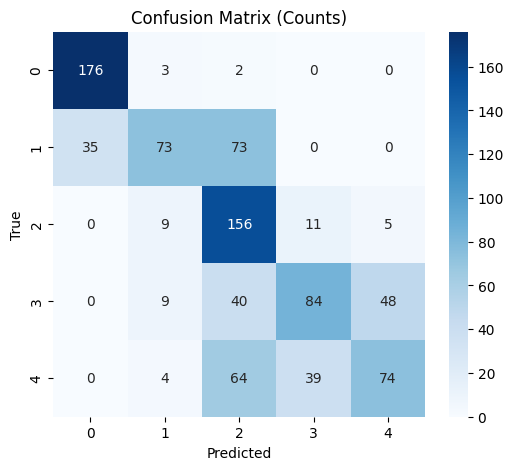

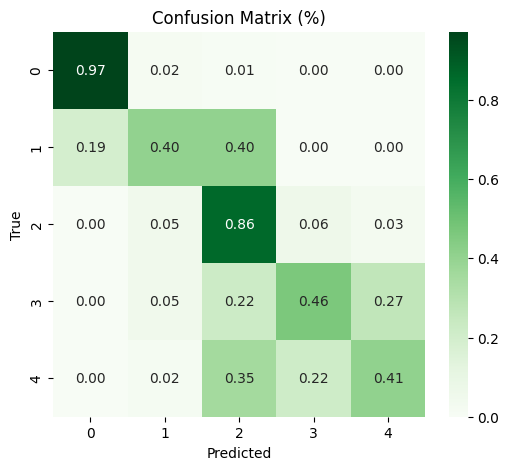

In [ ]:
# =========================
# CONFUSION MATRIX
# =========================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

# =========================
# GET TEST PREDICTIONS
# =========================
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, 1)

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(
    "Original counts:",
    np.bincount(y_true)
)

# =========================
# AUTO OVERSAMPLING
# =========================
class_counts = np.bincount(y_true)

max_count = np.max(class_counts)

indices = []

for c in range(len(class_counts)):

    class_idx = np.where(
        y_true == c
    )[0]

    if len(class_idx) < max_count:

        extra = np.random.choice(
            class_idx,
            max_count - len(class_idx),
            replace=True
        )

        selected = np.concatenate([
            class_idx,
            extra
        ])

    else:

        selected = class_idx

    indices.extend(selected)

indices = np.array(indices)

y_true_bal = y_true[indices]
y_pred_bal = y_pred[indices]

print(
    "Balanced counts:",
    np.bincount(y_true_bal)
)

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(
    y_true_bal,
    y_pred_bal
)

cm_norm = cm.astype(float) / cm.sum(
    axis=1,
    keepdims=True
)

labels = ["0", "1", "2", "3", "4"]

# =========================
# COMMON PLOT FUNCTION
# =========================
def plot_cm(matrix, title, fmt, cmap):

    plt.figure(figsize=(6,5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

# =========================
# PLOTS
# =========================
plot_cm(
    cm,
    "Confusion Matrix (Counts)",
    'd',
    "Blues"
)

plot_cm(
    cm_norm,
    "Confusion Matrix (%)",
    ".2f",
    "Greens"
)

In [ ]:
# =========================
# SAVE CONFUSION MATRICES
# =========================

import os

# =========================
# SAVE PATH
# =========================
SAVE_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"

os.makedirs(
    SAVE_PATH,
    exist_ok=True
)

labels = ["0", "1", "2", "3", "4"]

# =========================
# COMMON SAVE FUNCTION
# =========================
def save_cm(matrix, title, fmt, cmap, filename):

    plt.figure(figsize=(6,5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(title)

    plt.xlabel("Predicted")
    plt.ylabel("True")

    save_path = os.path.join(
        SAVE_PATH,
        filename
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight'
    )

    plt.close()

    print(f"Saved at: {save_path}")

# =========================
# SAVE MATRICES
# =========================
save_cm(
    cm,
    "Confusion Matrix (Counts)",
    'd',
    "Blues",
    "confusion_matrix_counts.png"
)

save_cm(
    cm_norm,
    "Confusion Matrix (Percentage)",
    ".2f",
    "Greens",
    "confusion_matrix_percentage.png"
)

Saved Counts CM at: /content/drive/MyDrive/DR_New_Results/APTOS/confusion_matrix_counts.png
Saved Percentage CM at: /content/drive/MyDrive/DR_New_Results/APTOS/confusion_matrix_percentage.png


In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score
)

# =========================
# SET SEED
# =========================
np.random.seed(42)
torch.manual_seed(42)

# =========================
# TEST PREDICTIONS
# =========================
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, 1)

        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# =========================
# TEST DISTRIBUTION
# =========================
print(
    "Original counts:",
    np.bincount(y_true)
)

# =========================
# ACCURACY
# =========================
accuracy = accuracy_score(
    y_true,
    y_pred
)

print(
    "\nTest Accuracy:",
    round(accuracy, 4)
)

# =========================
# CLASSIFICATION REPORT
# =========================
print(
    "\n=== ORIGINAL TEST REPORT ===\n"
)

print(
    classification_report(
        y_true,
        y_pred,
        digits=4,
        zero_division=0
    )
)

# =========================
# QWK
# =========================
qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights='quadratic'
)

print(
    "Test QWK:",
    round(qwk, 4)
)

Original counts: [181  37 100  19  30]

=== ORIGINAL TEST REPORT ===

              precision    recall  f1-score   support

           0     0.9670    0.9724    0.9697       181
           1     0.6250    0.4054    0.4918        37
           2     0.7250    0.8700    0.7909       100
           3     0.3913    0.4737    0.4286        19
           4     0.6667    0.4000    0.5000        30

    accuracy                         0.8147       367
   macro avg     0.6750    0.6243    0.6362       367
weighted avg     0.8122    0.8147    0.8064       367

Test QWK: 0.8969
Balanced counts: [181 181 181 181 181]

=== BALANCED CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

           0     0.8800    0.9724    0.9239       181
           1     0.7282    0.4144    0.5282       181
           2     0.4363    0.8895    0.5855       181
           3     0.5827    0.4088    0.4805       181
           4     0.6226    0.3646    0.4599       181

    accuracy      

In [ ]:
# =========================
# SAVE ORIGINAL REPORT
# =========================

import os

from sklearn.metrics import (
    classification_report,
    cohen_kappa_score
)

# =========================
# SAVE PATH
# =========================
SAVE_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS"

os.makedirs(
    SAVE_PATH,
    exist_ok=True
)

# =========================
# CREATE REPORT
# =========================
orig_report = classification_report(
    y_true,
    y_pred,
    digits=4,
    zero_division=0
)

qwk = cohen_kappa_score(
    y_true,
    y_pred,
    weights='quadratic'
)

# =========================
# SAVE TXT REPORT
# =========================
txt_path = os.path.join(
    SAVE_PATH,
    "original_report.txt"
)

with open(txt_path, "w") as f:

    f.write(
        "=== ORIGINAL TEST REPORT ===\n\n"
    )

    f.write(orig_report)

    f.write(f"\n\nQWK: {qwk:.4f}")

# =========================
# DONE
# =========================
print("Saved at:", txt_path)

 Saved in: /content/drive/MyDrive/DR_New_Results/APTOS
✔ original_report.txt
✔ balanced_report.txt
✔ original_report.png
✔ balanced_report.png


**Ablation Study **

In [ ]:
# ==========================================
# FAST + RESUMABLE ABLATION (FINAL)
# ==========================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

from PIL import Image

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    cohen_kappa_score
)

# =========================
# SPEED SETTINGS
# =========================
torch.backends.cudnn.benchmark = True

# =========================
# DEVICE
# =========================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =========================
# PATH
# =========================
SAVE_PATH = "/content/drive/MyDrive/DR_New_Results/APTOS/ablation_study"

os.makedirs(
    SAVE_PATH,
    exist_ok=True
)

# =========================
# LOAD DATA
# =========================
aptos_root = "/content/drive/MyDrive/Dataset/Full APTOS/2019"

df = pd.read_csv(
    os.path.join(aptos_root, "train.csv")
)

df.rename(
    columns={"diagnosis": "label"},
    inplace=True
)

# =========================
# IMAGE MAPPING
# =========================
image_dict = {}

for root, _, files in os.walk(aptos_root):

    for f in files:

        if f.endswith(".png"):

            image_dict[
                os.path.splitext(f)[0]
            ] = os.path.join(root, f)

df["image_path"] = df["id_code"].map(image_dict)

df = df.dropna().reset_index(drop=True)

# =========================
# SPLIT
# =========================
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# =========================
# DATASET
# =========================
class DRDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        img = Image.open(
            self.df.loc[idx, "image_path"]
        ).convert("RGB")

        label = self.df.loc[idx, "label"]

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(
            label,
            dtype=torch.long
        )

# =========================
# TRANSFORMS
# =========================
resize = transforms.Resize((224,224))

normalize = transforms.Normalize(
    [0.485,0.456,0.406],
    [0.229,0.224,0.225]
)

train_tf = transforms.Compose([
    resize,
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
])

val_tf = transforms.Compose([
    resize,
    transforms.ToTensor(),
    normalize
])

# =========================
# DATASETS
# =========================
train_dataset = DRDataset(
    train_df,
    train_tf
)

val_dataset = DRDataset(
    val_df,
    val_tf
)

# =========================
# DATALOADERS
# =========================
loader_kwargs = dict(
    batch_size=16,
    num_workers=2,
    pin_memory=True
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs
)

# =========================
# MODEL
# =========================
class DRModel(nn.Module):

    def __init__(
        self,
        use_cross=False,
        use_region=False
    ):

        super().__init__()

        backbone = efficientnet_b0(
            weights=EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        self.features = backbone.features

        dim = 1280

        self.use_cross = use_cross
        self.use_region = use_region

        self.cross = nn.Conv2d(
            dim,
            dim,
            1
        )

        self.region = nn.Sequential(

            nn.Conv2d(
                dim,
                dim // 4,
                1
            ),

            nn.ReLU(),

            nn.Conv2d(
                dim // 4,
                1,
                1
            ),

            nn.Sigmoid()
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Linear(dim, 5)

    def forward(self, x):

        x = self.features(x)

        if self.use_cross:
            x = x + self.cross(x)

        if self.use_region:
            x = x * self.region(x)

        x = self.pool(x).flatten(1)

        return self.fc(x)

# =========================
# TRAIN FUNCTION
# =========================
def train_model(config, name, epochs=10):

    model = DRModel(**config).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=3e-5
    )

    criterion = nn.CrossEntropyLoss()

    scaler = torch.cuda.amp.GradScaler()

    checkpoint_path = os.path.join(
        SAVE_PATH,
        f"{name}.pth"
    )

    start_epoch = 0

    # ================= RESUME =================
    if os.path.exists(checkpoint_path):

        print(f"Resuming {name}...")

        checkpoint = torch.load(
            checkpoint_path
        )

        model.load_state_dict(
            checkpoint["model"]
        )

        optimizer.load_state_dict(
            checkpoint["optimizer"]
        )

        start_epoch = checkpoint["epoch"] + 1

    # ================= TRAIN =================
    for epoch in range(start_epoch, epochs):

        model.train()

        for images, labels in train_loader:

            images = images.to(device)

            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            scaler.scale(loss).backward()

            scaler.step(optimizer)

            scaler.update()

        print(f"{name} → Epoch {epoch+1}/{epochs} done")

        # SAVE CHECKPOINT
        torch.save({

            "epoch": epoch,

            "model": model.state_dict(),

            "optimizer": optimizer.state_dict()

        }, checkpoint_path)

    # ================= VALIDATION =================
    model.eval()

    preds = []
    true = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            preds.extend(
                torch.argmax(outputs, 1).cpu().numpy()
            )

            true.extend(
                labels.numpy()
            )

    acc = accuracy_score(true, preds)

    f1 = f1_score(
        true,
        preds,
        average='weighted'
    )

    qwk = cohen_kappa_score(
        true,
        preds,
        weights='quadratic'
    )

    return acc, f1, qwk

# =========================
# EXPERIMENTS
# =========================
experiments = {

    "Baseline": {
        "use_cross": False,
        "use_region": False
    },

    "Cross": {
        "use_cross": True,
        "use_region": False
    },

    "Region": {
        "use_cross": False,
        "use_region": True
    },

    "Full": {
        "use_cross": True,
        "use_region": True
    }
}

# =========================
# RUN ABLATION
# =========================
results = []

for name, cfg in experiments.items():

    print("\nRunning:", name)

    acc, f1, qwk = train_model(
        cfg,
        name,
        epochs=10
    )

    results.append({

        "Model": name,

        "Accuracy": round(acc, 4),

        "F1": round(f1, 4),

        "QWK": round(qwk, 4)
    })

# =========================
# RESULTS
# =========================
df_results = pd.DataFrame(results)

print("\nFINAL RESULTS:\n")

print(df_results)

# =========================
# SAVE FILES
# =========================
csv_path = os.path.join(
    SAVE_PATH,
    "ablation.csv"
)

plot_path = os.path.join(
    SAVE_PATH,
    "ablation_plot.png"
)

# CSV
df_results.to_csv(
    csv_path,
    index=False
)

# =========================
# SAVE QWK PLOT
# =========================
plt.figure(figsize=(6,4))

plt.bar(
    df_results["Model"],
    df_results["QWK"]
)

plt.title("Ablation Study (QWK)")

plt.ylabel("QWK")

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches='tight'
)

plt.close()

print("\nDONE. All saved in:", SAVE_PATH)


Running: Baseline
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 115MB/s] 
/tmp/ipykernel_572/1576394098.py:158: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Resuming Baseline...

Running: Cross


/tmp/ipykernel_572/1576394098.py:158: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Resuming Cross...


...

Cross → Epoch 6/10 done
Cross → Epoch 7/10 done
Cross → Epoch 8/10 done
Cross → Epoch 9/10 done
Cross → Epoch 10/10 done

Running: Region


/tmp/ipykernel_572/1576394098.py:158: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_572/1576394098.py:181: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Region → Epoch 1/10 done
Region → Epoch 2/10 done
Region → Epoch 3/10 done
Region → Epoch 4/10 done
Region → Epoch 5/10 done
Region → Epoch 6/10 done
Region → Epoch 7/10 done
Region → Epoch 8/10 done
Region → Epoch 9/10 done
Region → Epoch 10/10 done

Running: Full


/tmp/ipykernel_572/1576394098.py:158: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_572/1576394098.py:181: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Full → Epoch 1/10 done
Full → Epoch 2/10 done
Full → Epoch 3/10 done
Full → Epoch 4/10 done
Full → Epoch 5/10 done
Full → Epoch 6/10 done
Full → Epoch 7/10 done
Full → Epoch 8/10 done
Full → Epoch 9/10 done
Full → Epoch 10/10 done

FINAL RESULTS:
       Model  Accuracy      F1     QWK
0  Baseline    0.8158  0.8053  0.8657
1     Cross    0.8049  0.8014  0.8486
2    Region    0.7926  0.7895  0.8470
3      Full    0.8090  0.8065  0.8441

 DONE. All saved in: /content/drive/MyDrive/DR_New_Results/APTOS/ablation_study
